In [ ]:
!pip install geopy # Install the geopy library for geographic calculations

In [ ]:
import json
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from decimal import Decimal
import urllib.request

panel_efficiency = 0.18  # 18% efficiency
panel_area = 1.6  # 1.6 m² per panel
phones = {
    "iPhone 15 Pro Max": 4422,
    "Nothing Phone (2)": 4700,
    "Xiaomi 14 Pro": 4880,
    "Samsung Galaxy S25 Ultra": 5000
}
import time
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
def get_center_coordinates(place_name: str):
    geolocator = Nominatim(user_agent="geo_center_finder")
    location = geolocator.geocode(place_name, timeout=10)
    
    if location:
        return (location.latitude, location.longitude)
    else:
        raise ValueError(f"Could not find coordinates for '{place_name}'")

def get_coords_from_input(place_name: str):
    center = None
    # Handle coordinates in parentheses or brackets
    if (place_name.startswith("(") and place_name.endswith(")")) or (place_name.startswith("[") and place_name.endswith("]")):
        center = (Decimal(place_name.split(",")[0].strip("()[]")), Decimal(place_name.split(",")[1].strip("()[]")))
    # Handle coordinates as a place name
    else:
        center = get_center_coordinates(place_name)
    print(f"Center of {place_name}: {center}")
    return center


place_name = input("Enter a place name (Disneyland), address (11122 NE 180th St, Bothell, WA 98011) or a set of coordinates in parentheses (47.65597163427398, -122.30944207919211): ")
center = get_coords_from_input(place_name)
latitude, longitude = center

# Allow the user to input a custom phone battery capacity
custom_phone_battery = input("Optional: Enter your phone battery capacity in mAh (or press Enter to skip): ")
custom_phone_name = ""
import re
if custom_phone_battery:
    # Removes commas, spaces, and non-numeric characters (like 'mAh' if entered) from the input
    clean_battery_input = re.sub(r'[^\d]', '', custom_phone_battery)
    
    if clean_battery_input:
        custom_phone_name = input("Optional: Enter your phone name (or press Enter to skip): ") or "Custom Phone"
        phones.update({custom_phone_name: int(clean_battery_input)})
# Sort phones by battery capacity
phones = dict(sorted(phones.items(), key=lambda item: item[1], reverse=True))
    


Center of Space Needle: (47.6205131, -122.3493036)


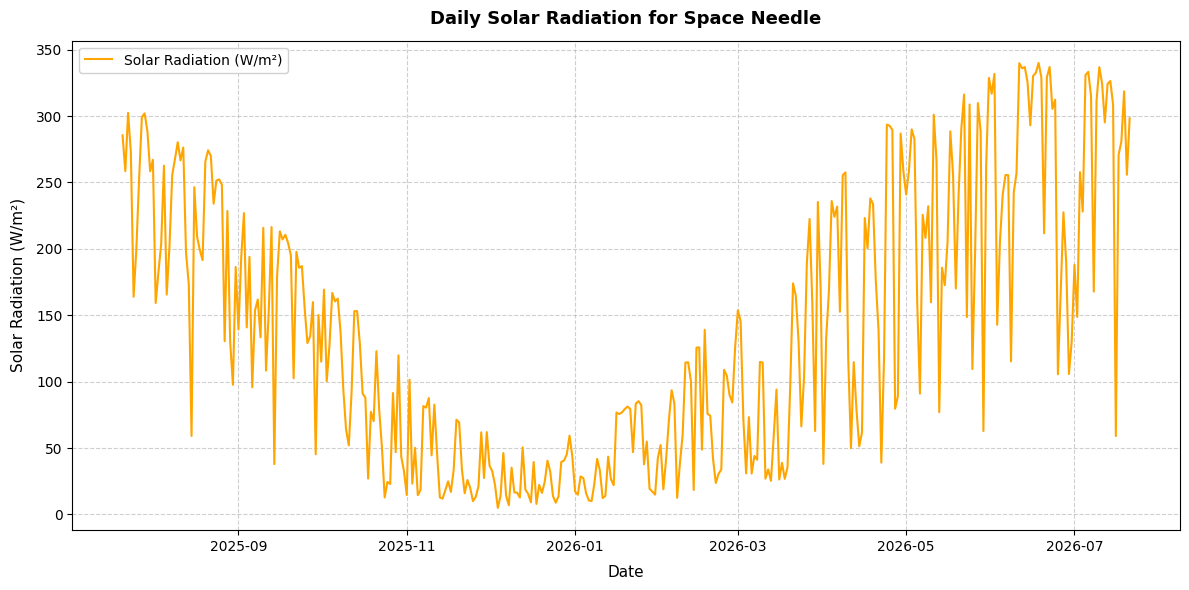

Analysis Period: 2025-07-21 to 2026-07-21
Minimum Solar Radiation: 4.9 W/m²
Maximum Solar Radiation: 340.0 W/m²


In [5]:
# Get the weather data for the specified coordinates
from datetime import datetime, date, timedelta

api_key = '298LYYNTAZVEU5JN67C8W5AQE'

# Queried Visual Crossing Timeline API for daily irradiance payload
def get_weather_data(lat, lon, start_date, end_date, api_key):
    url = (
        f'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{lat},{lon}/{start_date}/{end_date}'
        '?unitGroup=metric&elements=datetimeEpoch,solarradiation'
        f'&key={api_key}&contentType=json'
    )
    response = urllib.request.urlopen(url).read()
    return json.loads(response)

# Extracted epoch timestamps and radiation values into structured DataFrame
def convert_to_dataframe(weather_data):
    records = [
        {
            'date': datetime.fromtimestamp(day['datetimeEpoch']),
            'solar_radiation': day.get('solarradiation', 0)
        }
        for day in weather_data['days']
    ]
    df = pd.DataFrame(records)
    df.set_index('date', inplace=True)
    return df

# Rendered annual solar radiation time-series plot
def plot_solar_radiation(df):
    plt.figure(figsize=(12, 6), dpi=100)
    plt.plot(df.index, df['solar_radiation'], label='Solar Radiation (W/m²)', color='orange', linewidth=1.5)
    plt.title(f'Daily Solar Radiation for {place_name}', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Date', fontsize=11, labelpad=8)
    plt.ylabel('Solar Radiation (W/m²)', fontsize=11, labelpad=8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

# Computed daily panel requirements based on nominal voltage specifications
def calculate_solar_panels_needed(solar_radiation_watts, panel_efficiency, panel_area, phone_capacity_mah):
    solar_radiation_kw = solar_radiation_watts / 1000
    phone_capacity_kwh = (phone_capacity_mah * 3.85) / 1_000_000  
    energy_per_panel_per_day = solar_radiation_kw * panel_efficiency * panel_area 
    
    if energy_per_panel_per_day == 0:
        return float('inf')  
    return phone_capacity_kwh / energy_per_panel_per_day

# Calculated rolling 365-day date range relative to current execution date
today = date.today()
end_date_str = (today - timedelta(days=2)).strftime('%Y-%m-%d')
start_date_str = (today - timedelta(days=367)).strftime('%Y-%m-%d')

# Fetched most recent meteorological dataset and visualized annual trends
weather_data = get_weather_data(latitude, longitude, start_date_str, end_date_str, api_key)
df = convert_to_dataframe(weather_data)
plot_solar_radiation(df)

# Extracted minimum and maximum irradiance metrics
min_solar_radiation = df['solar_radiation'].min()
max_solar_radiation = df['solar_radiation'].max()
print(f"Analysis Period: {df.index.min().date()} to {df.index.max().date()}")
print(f"Minimum Solar Radiation: {min_solar_radiation} W/m²")
print(f"Maximum Solar Radiation: {max_solar_radiation} W/m²")

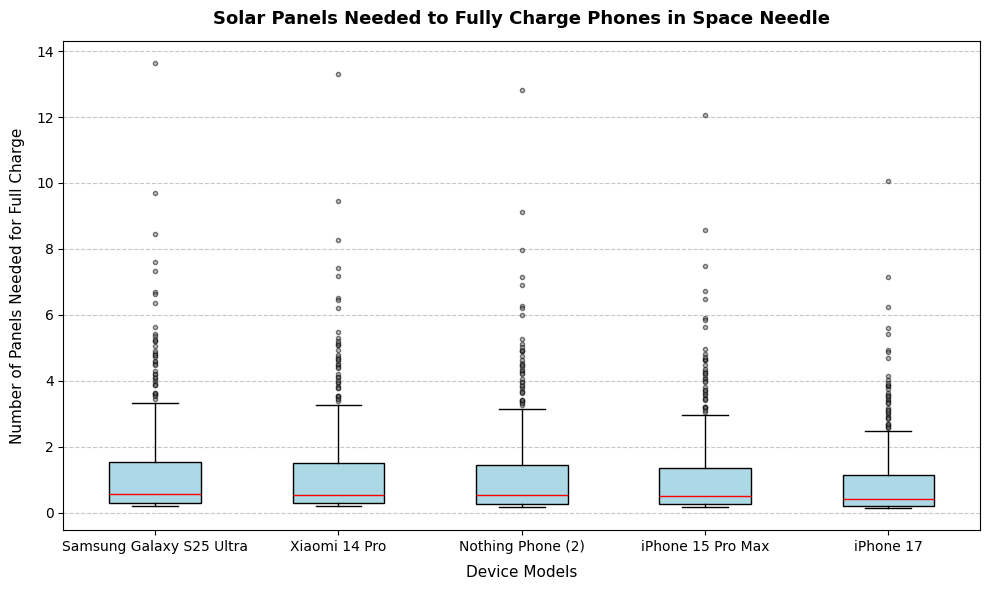

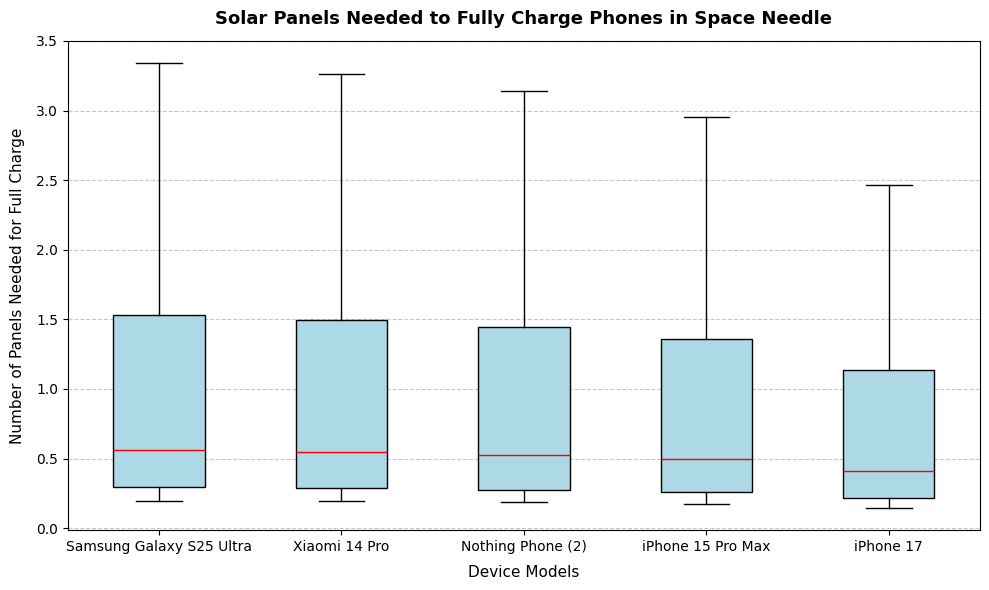

In [6]:
# Generated box plots showing distribution of required panel counts per device
def plot_box_and_whisker_full(df, phones, panel_efficiency=0.18, panel_area=1.6, show_outliers=True):
    """
    Draws a box-and-whisker plot for each phone, showing the distribution of solar panels
    needed per day throughout the year.
    """
    phone_data = {}

    for phone, capacity in phones.items():
        # Converted battery capacity to kWh using nominal voltage and calculated panel needs
        phone_capacity_kwh = (capacity * 3.85) / 1_000_000
        energy_per_panel_per_day = (df['solar_radiation'] / 1000) * panel_efficiency * panel_area
        panels_needed = phone_capacity_kwh / energy_per_panel_per_day.replace(0, float('nan'))
        phone_data[phone] = panels_needed

    # Standardized outlier marker styling
    flierprops = dict(marker='o', markersize=3, linestyle='none', markerfacecolor='gray', alpha=0.5)

    # Plotted statistical quartiles, medians, and extremes per model
    plt.figure(figsize=(10, 6), dpi=100)
    plt.boxplot(
        phone_data.values(), 
        tick_labels=phone_data.keys(), 
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='black'),
        medianprops=dict(color='red'),
        flierprops=flierprops,
        showfliers=show_outliers
    )

    plt.title(f"Solar Panels Needed to Fully Charge Phones in {place_name}", fontsize=13, fontweight='bold', pad=12)
    plt.ylabel("Number of Panels Needed for Full Charge", fontsize=11, labelpad=8)
    plt.xlabel("Device Models", fontsize=11, labelpad=8)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Rendered distributions with and without seasonal extremes
plot_box_and_whisker_full(df, phones, panel_efficiency, panel_area, show_outliers=True)
plot_box_and_whisker_full(df, phones, panel_efficiency, panel_area, show_outliers=False)

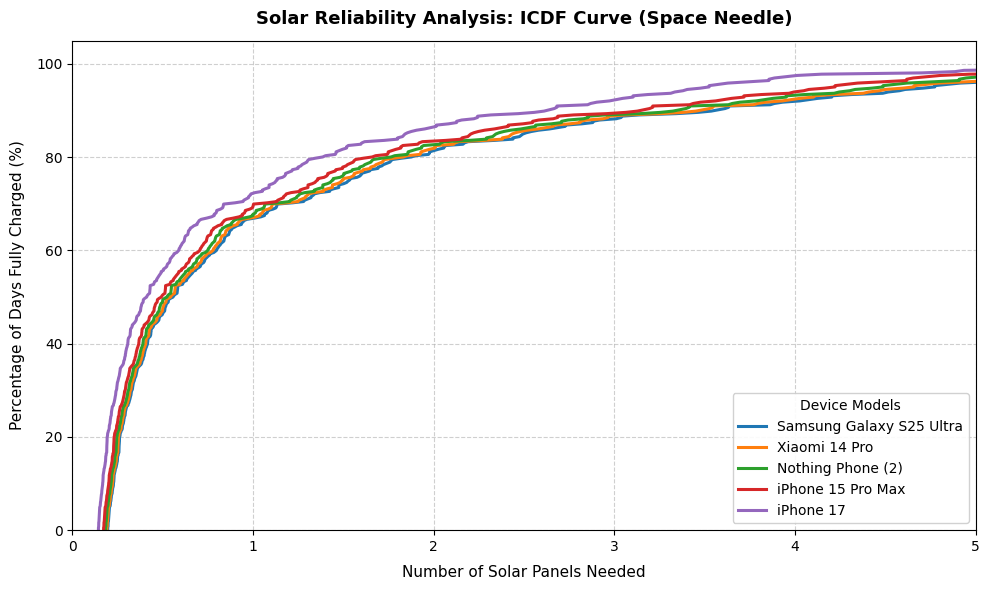

In [7]:
# Computed daily panel requirements and generated inverse CDF curves per device
def plot_icdf(df, phones, panel_efficiency=0.18, panel_area=1.6):
    """
    Plots the Inverse Cumulative Distribution Function (ICDF) showing the 
    percentage of days a battery will be fully charged vs. number of panels.
    """
    phone_data = {}

    for phone, capacity in phones.items():
        # Converted battery capacity to kWh using nominal voltage and derived daily panel yields
        phone_capacity_kwh = (capacity * 3.85) / 1_000_000
        energy_per_panel_day = (df['solar_radiation'] / 1000) * panel_efficiency * panel_area
        
        # Mapped required panel count per day while filtering zero-radiation instances
        panels_needed = phone_capacity_kwh / energy_per_panel_day.replace(0, float('nan'))
        phone_data[phone] = panels_needed

    # Calculated empirical percentiles for charging reliability
    icdf_data = {}
    for phone, panels in phone_data.items():
        sorted_panels = sorted(panels.dropna())
        percentiles = [(i + 1) / len(sorted_panels) * 100 for i in range(len(sorted_panels))]
        icdf_data[phone] = pd.Series(percentiles, index=sorted_panels)

    # Configured visual styling and axis constraints for consumer panel ranges
    plt.figure(figsize=(10, 6), dpi=100)
    
    for phone, icdf in icdf_data.items():
        plt.plot(icdf.index, icdf.values, label=phone, linewidth=2.2)

    plt.title(f"Solar Reliability Analysis: ICDF Curve ({place_name})", fontsize=13, fontweight='bold', pad=12)
    plt.xlabel("Number of Solar Panels Needed", fontsize=11, labelpad=8)
    plt.ylabel("Percentage of Days Fully Charged (%)", fontsize=11, labelpad=8)
    
    # Capped scale at 5 panels to handle cloudy-day outliers cleanly
    plt.xlim(0, 5)  
    plt.ylim(0, 105)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Device Models", frameon=True, facecolor='white', framealpha=0.9)
    plt.tight_layout()
    plt.show()

# Rendered reliability curves for analysis
plot_icdf(df, phones, panel_efficiency, panel_area)

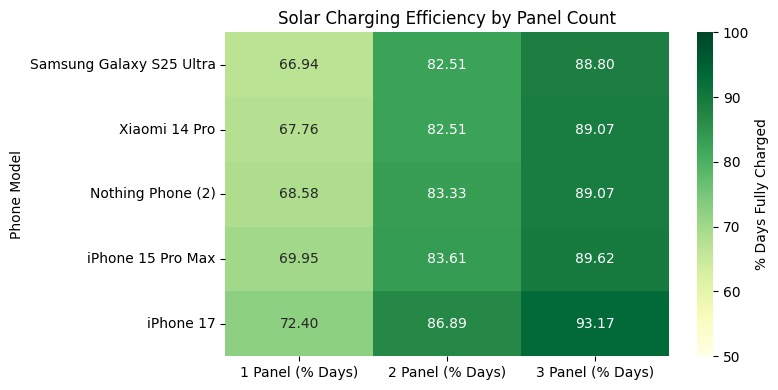

In [9]:
import seaborn as sns
def generate_charging_table(df, phones, panel_efficiency=0.18, panel_area=1.6):
    records = []
    
    for phone, capacity in phones.items():
        phone_capacity_kwh = (capacity * 3.7) / 1_000_000
        energy_per_panel = (df['solar_radiation'] / 1000) * panel_efficiency * panel_area
        
        row = {"Phone Model": phone}
        for n in [1, 2, 3]:
            days_charged = ((energy_per_panel * n) >= phone_capacity_kwh).sum()
            pct = (days_charged / len(df)) * 100
            row[f"{n} Panel (% Days)"] = pct
            
        records.append(row)
        
    summary_df = pd.DataFrame(records).set_index("Phone Model")
    return summary_df

# 1. Generate the DataFrame
summary_df = generate_charging_table(df, phones, panel_efficiency, panel_area)

# 2. Plot as a Seaborn Heatmap Image (GitHub displays this natively)
plt.figure(figsize=(8, 4))
sns.heatmap(summary_df, annot=True, fmt=".2f", cmap="YlGn", vmin=50, vmax=100, cbar_kws={'label': '% Days Fully Charged'})
plt.title("Solar Charging Efficiency by Panel Count")
plt.tight_layout()
plt.show()